In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import hankel1


In [2]:
class AcousticSimulator2D:
    def __init__(self, freqs, targets, c=1500):
        self.freqs = freqs
        self.targets = targets
        self.k_vec = 2 * np.pi * np.array(freqs) / c

    def generate_msr(self, n_sensors=15, radius=10):
        angles = np.linspace(0, 2*np.pi, n_sensors, endpoint=False)
        sensors = radius * np.c_[np.cos(angles), np.sin(angles)]
        msr_all = []

        for k in self.k_vec:
            n_t = len(self.targets)
            T = np.eye(n_t, dtype=complex)

            for i in range(n_t):
                for j in range(n_t):
                    if i != j:
                        r = np.linalg.norm(self.targets[i] - self.targets[j])
                        T[i, j] = (1j/4) * hankel1(0, k*r)

            T_inv = np.linalg.inv(T)

            G = np.zeros((n_t, n_sensors), dtype=complex)
            for i in range(n_t):
                for j in range(n_sensors):
                    r = np.linalg.norm(self.targets[i] - sensors[j])
                    G[i, j] = (1j/4) * hankel1(0, k*r)

            msr_all.append(G.T @ T_inv @ G)

        return msr_all, angles

    def add_noise(self, msr, snr_db):
        noisy = []
        for M in msr:
            p = np.mean(np.abs(M)**2)
            npow = p / (10**(snr_db/10))
            noise = np.sqrt(npow/2)*(np.random.randn(*M.shape)+1j*np.random.randn(*M.shape))
            noisy.append(M + noise)
        return noisy


In [3]:
def soft_thresh(z, t):
    mag = np.abs(z)
    return np.maximum(0, mag-t)/(mag+1e-12)*z

def fista(A, b, lam, iters=120):
    g = np.zeros(A.shape[1], dtype=complex)
    y, t = g.copy(), 1
    L = np.linalg.norm(A, 2)**2
    step = 1/L

    for _ in range(iters):
        grad = A.conj().T @ (A@y - b)
        g2 = soft_thresh(y - step*grad, lam*step)
        t2 = (1 + np.sqrt(1+4*t*t))/2
        y = g2 + (t-1)/t2*(g2-g)
        g, t = g2, t2
    return g


In [13]:
def indicator(A, g):
    return np.linalg.norm(A@g)/(np.linalg.norm(g)+1e-6)

def solve_lsm_2d(msr, k_vec, angles, grid=30, lim=3):
    x = np.linspace(-lim, lim, grid)
    y = np.linspace(-lim, lim, grid)
    X, Y = np.meshgrid(x, y)
    img = np.zeros_like(X)

    sx, sy = 10*np.cos(angles), 10*np.sin(angles)
    weights = (k_vec/np.max(k_vec))**2

    for i in range(grid):
        for j in range(grid):
            z = np.array([X[i,j], Y[i,j]])
            A, b = [], []

            for w, k, M in zip(weights, k_vec, msr):
                r = np.sqrt((sx-z[0])**2+(sy-z[1])**2)
                Phi = (1j/4)*hankel1(0, k*r)
                A.append(np.sqrt(w)*M)
                b.append(np.sqrt(w)*Phi)

            A = np.vstack(A)
            b = np.hstack(b)
            g = fista(A, b, lam=0.35)
            img[i,j] = indicator(A, g)

    max_val = img.max()
    if max_val == 0:
        return img, X, Y
    return img/max_val, X, Y

In [5]:
def detect(img, X, Y, targets, th, tol=0.3):
    hit = 0
    for t in targets:
        d = np.sqrt((X-t[0])**2+(Y-t[1])**2)
        if np.any(img[d<tol] > th):
            hit += 1
    return hit/len(targets)

def false_alarm(img, X, Y, targets, th, tol=0.3):
    mask = np.ones_like(img, bool)
    for t in targets:
        d = np.sqrt((X-t[0])**2+(Y-t[1])**2)
        mask &= (d > tol)
    return np.sum(img[mask] > th)/np.sum(mask)

def roc_curve(sim, targets, thresholds, snr=15, trials=15):
    Pd, Pfa = np.zeros(len(thresholds)), np.zeros(len(thresholds))

    for _ in range(trials):
        msr, ang = sim.generate_msr()
        msr = sim.add_noise(msr, snr)
        img, X, Y = solve_lsm_2d(msr, sim.k_vec, ang)

        for i, th in enumerate(thresholds):
            Pd[i] += detect(img, X, Y, targets, th)
            Pfa[i] += false_alarm(img, X, Y, targets, th)

    return Pfa/trials, Pd/trials


In [14]:
def greens_3d(k, r):
    return np.exp(1j*k*r)/(4*np.pi*r+1e-9)

def spherical_array(n_th=6, n_ph=12, R=10):
    S = []
    for t in np.linspace(0,np.pi,n_th):
        for p in np.linspace(0,2*np.pi,n_ph):
            S.append([R*np.sin(t)*np.cos(p),
                      R*np.sin(t)*np.sin(p),
                      R*np.cos(t)])
    return np.array(S)

def solve_lsm_3d(msr, k_vec, sensors, lim=3, N=18):
    grid = np.linspace(-lim, lim, N)
    img = np.zeros((N,N,N))

    for ix,x in enumerate(grid):
        for iy,y in enumerate(grid):
            for iz,z in enumerate(grid):
                zp = np.array([x,y,z])
                A,b = [],[]

                for k,M in zip(k_vec, msr):
                    r = np.linalg.norm(sensors-zp,axis=1)
                    Phi = greens_3d(k,r)
                    A.append(M)
                    b.append(Phi)

                A = np.vstack(A)
                b = np.hstack(b)
                g = fista(A,b,lam=0.4)
                img[ix,iy,iz] = indicator(A,g)

    max_val = img.max()
    if max_val == 0:
        return img
    return img/max_val

In [7]:
if __name__ == "__main__":

    freqs = [2000,3000,4000]
    targets = np.array([[-1.5,0],[0,0],[1.5,0],[0,2]])

    sim = AcousticSimulator2D(freqs, targets)


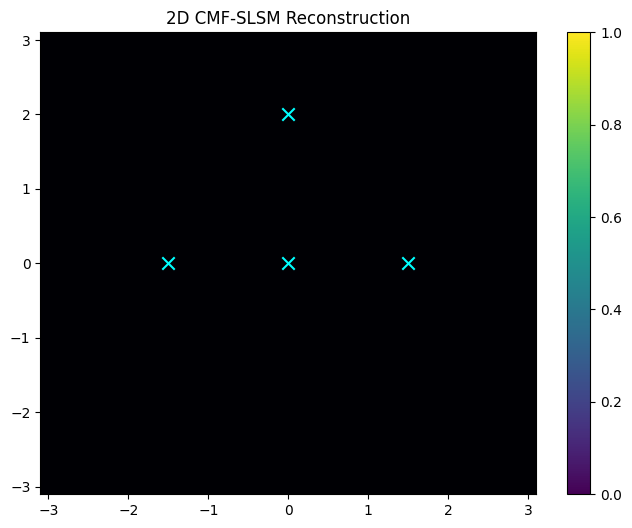

In [17]:
 # ---- 2D Imaging
msr, ang = sim.generate_msr()
msr = sim.add_noise(msr, snr_db=15)
img, X, Y = solve_lsm_2d(msr, sim.k_vec, ang)

plt.figure(figsize=(8,6))
plt.pcolormesh(X,Y,img,cmap="inferno")
plt.scatter(targets[:,0],targets[:,1],c="cyan",marker="x",s=80)
plt.title("2D CMF-SLSM Reconstruction")
plt.colorbar()
plt.show()

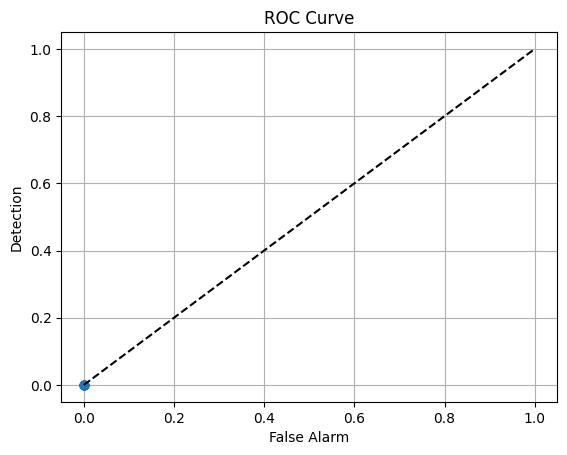

In [16]:
# ---- ROC
th = np.linspace(0.1,0.9,25)
Pfa, Pd = roc_curve(sim, targets, th)

plt.figure()
plt.plot(Pfa,Pd,"-o")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Alarm")
plt.ylabel("Detection")
plt.title("ROC Curve")
plt.grid()
plt.show()


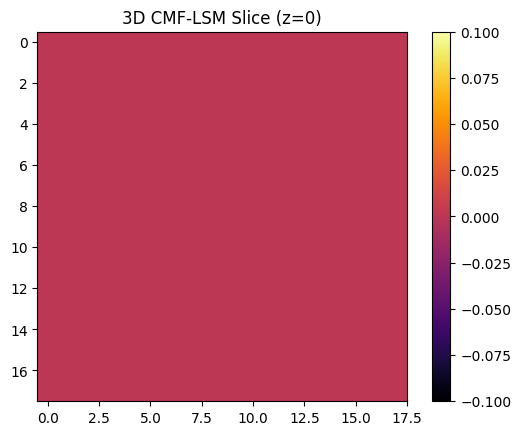

In [15]:
sensors3d = spherical_array()
msr3d = []
for k in sim.k_vec:
    msr3d.append(np.eye(len(sensors3d),dtype=complex))

vol = solve_lsm_3d(msr3d, sim.k_vec, sensors3d)
mid = vol.shape[2]//2

plt.imshow(vol[:,:,mid],cmap="inferno")
plt.title("3D CMF-LSM Slice (z=0)")
plt.colorbar()
plt.show()